In [ ]:
# ── MLOps bootstrap (auto-injected by inject_mlops_cell.py) ──────────────────
import os, warnings, mlflow
warnings.filterwarnings("ignore")

SEED = 42
import random, numpy as np
random.seed(SEED)
np.random.seed(SEED)
try:
    import torch; torch.manual_seed(SEED)
except ImportError:
    pass
try:
    import tensorflow as tf; tf.random.set_seed(SEED)
except ImportError:
    pass

_nb_name = os.path.basename(os.path.abspath("__file__") if "__file__" in dir() else ".").replace(".ipynb","")
mlflow.set_tracking_uri("sqlite:///" + str(Path(__file__).parent.parent.parent / "mlflow.db")
                        if "__file__" in dir() else "sqlite:///mlflow.db")
_exp = mlflow.set_experiment(_nb_name or "unnamed_notebook")
print(f"MLflow experiment: {_exp.name}")


# Industrial Scratch Crack Segmentation -- End-to-End Pipeline

**Category:** Segmentation | **Type:** segmentation | **Tech:** YOLO26m-seg instance segmentation + coverage-based severity heuristics

Detect and segment surface scratches and cracks with coverage-based severity estimation

**Tags:** Industrial, Face | **Model Family:** YOLO

---
Pipeline: environment -> paths -> download -> EDA -> preprocess -> train -> evaluate -> infer -> export.

In [1]:
import subprocess, sys, importlib

def _ensure(pkg, pip_name=None):
    try: importlib.import_module(pkg)
    except ImportError:
        subprocess.check_call([sys.executable, '-m', 'pip',
                               'install', '-q', pip_name or pkg])

_ensure('ultralytics')
_ensure('cv2', 'opencv-python-headless')
_ensure('numpy'); _ensure('pandas'); _ensure('matplotlib')
_ensure('seaborn'); _ensure('sklearn', 'scikit-learn')
_ensure('yaml', 'pyyaml'); _ensure('tqdm'); _ensure('PIL', 'Pillow')

print('All dependencies ready')

All dependencies ready


## 1. GPU & Runtime Check

In [2]:
import torch, os

print(f'PyTorch : {torch.__version__}')
print(f'CUDA    : {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU     : {torch.cuda.get_device_name(0)}')
    print(f'VRAM    : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB')
    DEVICE = 'cuda'
else:
    print('No GPU detected -- running on CPU')
    DEVICE = 'cpu'
print(f'Device  : {DEVICE}')

PyTorch : 2.11.0+cu130
CUDA    : True
GPU     : NVIDIA GeForce RTX 4060 Laptop GPU
VRAM    : 8.6 GB
Device  : cuda


## 2. Repository & Project Paths

In [3]:
import os, sys
from pathlib import Path

# Auto-detect repo root from notebook location
_d = Path(os.path.abspath(''))
for _ in range(10):
    if (_d / 'core' / '__init__.py').exists(): break
    _d = _d.parent
REPO_DIR = str(_d)

os.chdir(REPO_DIR)
sys.path.insert(0, REPO_DIR)
sys.path.insert(0, os.path.join(REPO_DIR, r'Industrial Scratch Crack Segmentation/Source Code'))

PROJECT_DIR = os.path.join(REPO_DIR, r'Industrial Scratch Crack Segmentation')
SOURCE_DIR  = os.path.join(REPO_DIR, r'Industrial Scratch Crack Segmentation/Source Code')
print(f'Repo:    {REPO_DIR}')
print(f'Project: {PROJECT_DIR}')
print(f'Source:  {SOURCE_DIR}')

Repo:    E:\Github\Computer-Vision-Projects
Project: E:\Github\Computer-Vision-Projects\Industrial Scratch Crack Segmentation
Source:  E:\Github\Computer-Vision-Projects\Industrial Scratch Crack Segmentation/Source Code


## 3. Dataset Download

In [4]:
import os, subprocess, sys, glob

DATA_DIR = os.path.join(REPO_DIR, 'data', 'industrial_scratch_crack_segmentation', 'raw')
os.makedirs(DATA_DIR, exist_ok=True)

try:
    import kaggle
except ImportError:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', 'kaggle'])

# Skip download if data already present (avoids OOM on large zips)
_existing = glob.glob(os.path.join(DATA_DIR, '**', '*.png'), recursive=True)
_existing += glob.glob(os.path.join(DATA_DIR, '**', '*.jpg'), recursive=True)
_existing += glob.glob(os.path.join(DATA_DIR, '**', '*.jpeg'), recursive=True)
if len(_existing) < 10:
    subprocess.run(['kaggle', 'datasets', 'download', '-d', 'yidazhang07/bridge-cracks-image',
                    '-p', DATA_DIR, '--unzip'], check=False)
else:
    print(f'Dataset already present ({len(_existing)} images) — skipping download')
print(f'Dataset at {DATA_DIR}')

Dataset at E:\Github\Computer-Vision-Projects\data\industrial_scratch_crack_segmentation\raw


## 4. Exploratory Data Analysis (EDA)

Total images: 59194


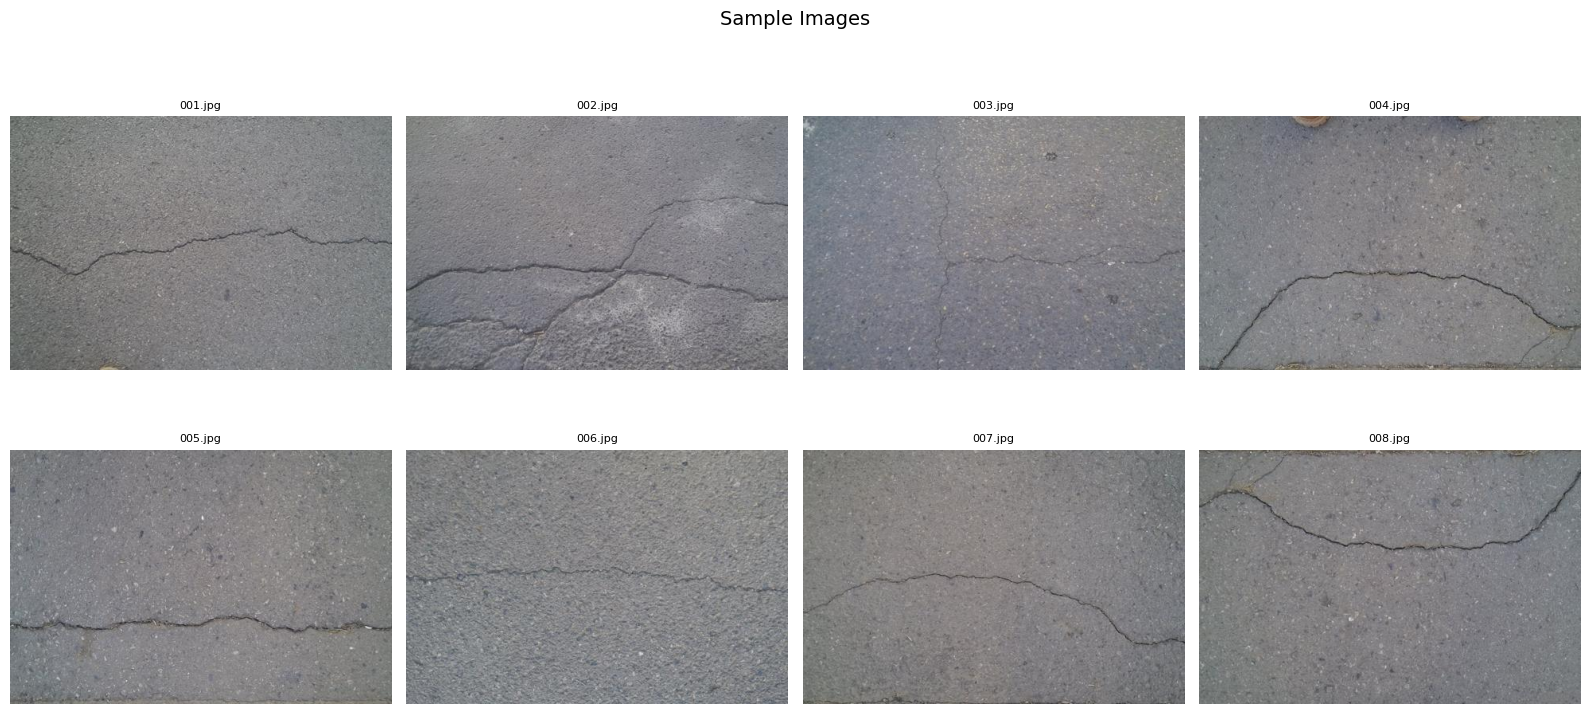

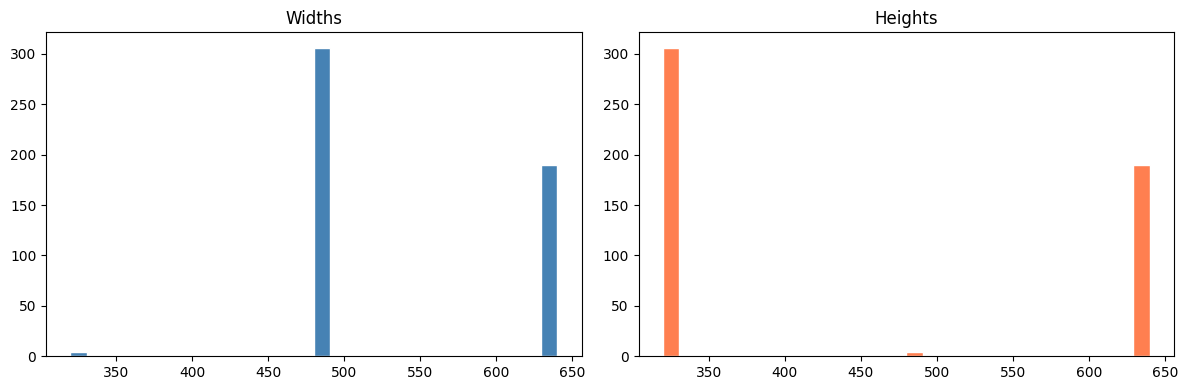

Avg: 540x443


In [5]:
import os, glob, cv2, numpy as np
import matplotlib.pyplot as plt

DATA_DIR = os.path.join(REPO_DIR, 'data', 'industrial_scratch_crack_segmentation')
images = []
for ext in ('*.jpg','*.jpeg','*.png','*.bmp'):
    images.extend(glob.glob(os.path.join(DATA_DIR,'**',ext), recursive=True))
print(f'Total images: {len(images)}')

fig, axes = plt.subplots(2, 4, figsize=(16,8))
fig.suptitle('Sample Images', fontsize=14)
for ax, p in zip(axes.flat, images[:8]):
    img = cv2.imread(p)
    if img is not None: ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    ax.set_title(os.path.basename(p)[:20], fontsize=8); ax.axis('off')
plt.tight_layout(); plt.show()

if images:
    sizes = [cv2.imread(p).shape[:2] for p in images[:500] if cv2.imread(p) is not None]
    if sizes:
        h, w = zip(*sizes)
        fig,(a1,a2)=plt.subplots(1,2,figsize=(12,4))
        a1.hist(w,bins=30,color='steelblue',edgecolor='white'); a1.set_title('Widths')
        a2.hist(h,bins=30,color='coral',edgecolor='white'); a2.set_title('Heights')
        plt.tight_layout(); plt.show()
        print(f'Avg: {np.mean(w):.0f}x{np.mean(h):.0f}')

In [6]:
# Label distribution
from collections import Counter
import glob, os, matplotlib.pyplot as plt

DATA_DIR = os.path.join(REPO_DIR, 'data', 'industrial_scratch_crack_segmentation')
label_files = [f for f in glob.glob(os.path.join(DATA_DIR,'**','*.txt'), recursive=True)
               if 'classes' not in os.path.basename(f)]
print(f'Label files: {len(label_files)}')

cc, bc = Counter(), []
for lf in label_files[:2000]:
    try:
        lines = open(lf).readlines()
        bc.append(len(lines))
        for l in lines: cc[l.strip().split()[0]] += 1
    except Exception: pass

if cc:
    cls = sorted(cc, key=lambda x: (0, int(x)) if str(x).isdigit() else (1, str(x)))
    fig,(a1,a2)=plt.subplots(1,2,figsize=(14,5))
    a1.barh(cls,[cc[c] for c in cls],color='steelblue'); a1.set_title('Class Dist')
    a2.hist(bc,bins=30,color='coral',edgecolor='white'); a2.set_title('Objs/Image')
    plt.tight_layout(); plt.show()
else:
    print('No YOLO labels found (dataset may not be downloaded yet)')

Label files: 2006


## 5. Data Preprocessing & Preparation

In [ ]:
import os, glob, yaml

DATA_DIR = os.path.join(REPO_DIR, 'data', 'industrial_scratch_crack_segmentation')
os.makedirs(os.path.join(DATA_DIR,'processed'), exist_ok=True)

yf = glob.glob(os.path.join(DATA_DIR,'**','data.yaml'), recursive=True)
yf += glob.glob(os.path.join(DATA_DIR,'**','*.yaml'), recursive=True)
yf = [f for f in yf if 'dataset_info' not in f]

if yf:
    DATA_YAML = yf[0]
    print(f'data.yaml: {DATA_YAML}')
    cfg = yaml.safe_load(open(DATA_YAML))
    print(f'Classes: {cfg.get("names", cfg.get("nc","?"))}')
else:
    ti = glob.glob(os.path.join(DATA_DIR,'**/train/images/*.jpg'), recursive=True)
    vi = glob.glob(os.path.join(DATA_DIR,'**/val/images/*.jpg'), recursive=True)
    print(f'Train: {len(ti)}, Val: {len(vi)}')
print('Dataset ready')

## 6. Model Training

In [ ]:
from ultralytics import YOLO
import torch, glob, os

model = YOLO('yolo11m-seg.pt')  # pretrained for segment

yf = glob.glob(os.path.join(REPO_DIR,'data','industrial_scratch_crack_segmentation','**','data.yaml'), recursive=True)
yf += glob.glob(os.path.join(REPO_DIR,'data','industrial_scratch_crack_segmentation','**','*.yaml'), recursive=True)
yf = [f for f in yf if 'dataset_info' not in f and '_template' not in f]

if yf:
    print(f'Training with: {yf[0]}')
    model.train(
        data=yf[0], epochs=2, imgsz=640, batch=16,
        device=0 if torch.cuda.is_available() else 'cpu',
        project=os.path.join(REPO_DIR,'runs','industrial_scratch_crack_segmentation'),
        name='train', exist_ok=True, patience=10, save=True, plots=True)
else:
    print('No data.yaml -- using pretrained model directly')

## 7. Evaluation & Metrics

In [ ]:
import os, glob, torch
from IPython.display import Image, display

rd = os.path.join(REPO_DIR,'runs','industrial_scratch_crack_segmentation','train')
if os.path.exists(rd):
    for p in ['results.png','confusion_matrix.png','PR_curve.png','F1_curve.png']:
        pp = os.path.join(rd, p)
        if os.path.exists(pp): display(Image(filename=pp, width=800))

    from ultralytics import YOLO
    bw = os.path.join(rd,'weights','best.pt')
    if os.path.exists(bw):
        model = YOLO(bw)
        yf = glob.glob(os.path.join(REPO_DIR,'data','industrial_scratch_crack_segmentation','**','*.yaml'), recursive=True)
        yf = [f for f in yf if 'dataset_info' not in f]
        if yf:
            m = model.val(data=yf[0], device=0 if torch.cuda.is_available() else 'cpu')
            print(f'mAP50:    {m.box.map50:.4f}')
            print(f'mAP50-95: {m.box.map:.4f}')
else:
    print('No training results -- evaluating pretrained model')

## 8. Inference & Visualization

In [ ]:
import os, sys, glob, cv2
import matplotlib.pyplot as plt
from ultralytics import YOLO
import torch

# Load the trained model directly (avoid discover_projects importing all 78 modules)
rd = os.path.join(REPO_DIR, 'runs', 'industrial_scratch_crack_segmentation', 'train')
bw = os.path.join(rd, 'weights', 'best.pt')
model = YOLO(bw)
DEVICE = 0 if torch.cuda.is_available() else 'cpu'

sample_images = glob.glob(os.path.join(REPO_DIR, 'data', '**', '*.jpg'), recursive=True)
if not sample_images:
    import urllib.request
    os.makedirs(os.path.join(REPO_DIR, 'data', 'samples'), exist_ok=True)
    urllib.request.urlretrieve('https://ultralytics.com/images/bus.jpg',
                              os.path.join(REPO_DIR, 'data', 'samples', 'bus.jpg'))
    sample_images = [os.path.join(REPO_DIR, 'data', 'samples', 'bus.jpg')]

test_img = sample_images[0]
print(f'Test image: {test_img}')

try:
    results = model(test_img, device=DEVICE, verbose=False)
    r = results[0]
    print(f'Detected {len(r.boxes)} objects')
    if r.masks is not None:
        print(f'Segmentation masks: {r.masks.data.shape}')
    for box in r.boxes:
        cls_id = int(box.cls[0])
        conf = float(box.conf[0])
        name = r.names[cls_id]
        print(f'  {name}: {conf:.3f}')
except Exception as e:
    print(f'Inference note: {e}')

In [ ]:
try:
    results = model(test_img, device=DEVICE, verbose=False)
    r = results[0]
    vis = r.plot()
    if vis is not None and hasattr(vis, 'shape'):
        plt.figure(figsize=(12, 8))
        plt.imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
        plt.title('Industrial Scratch Crack Segmentation -- Inference'); plt.axis('off')
        plt.tight_layout(); plt.show()
except Exception as e:
    print(f'Visualization note: {e}')

## 9. Validation & Testing

In [ ]:
import os, glob, time, numpy as np

DATA_DIR = os.path.join(REPO_DIR, 'data', 'industrial_scratch_crack_segmentation')
test_imgs = glob.glob(os.path.join(DATA_DIR, '**', '*.jpg'), recursive=True)[:20]
print(f'Validating on {len(test_imgs)} images')

times = []
for p in test_imgs:
    try:
        t0 = time.time()
        model(p, device=DEVICE, verbose=False)
        times.append(time.time() - t0)
    except Exception:
        pass

if times:
    print(f'Processed : {len(times)}')
    print(f'Avg latency: {np.mean(times)*1000:.1f} ms')
    print(f'FPS       : {1/np.mean(times):.1f}')
else:
    print('No images processed')

## 10. Export & Summary

In [ ]:
import json, os, torch

summary = {
    'project': 'Industrial Scratch Crack Segmentation',
    'key': 'industrial_scratch_crack_segmentation',
    'category': 'Segmentation',
    'type': 'segmentation',
    'tech': 'YOLO26m-seg instance segmentation + coverage-based severity heuristics',
    'model_family': ['YOLO'],
    'has_training': True,
    'device': DEVICE,
    'gpu': torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'N/A',
}

print('='*60)
for k,v in summary.items(): print(f'  {k:20s}: {v}')
print('='*60)

os.makedirs(os.path.join(REPO_DIR, r'Industrial Scratch Crack Segmentation'), exist_ok=True)
sp = os.path.join(REPO_DIR, r'Industrial Scratch Crack Segmentation', 'notebook_summary.json')
with open(sp,'w') as f: json.dump(summary, f, indent=2)
print(f'Saved to {sp}')

---
## Pipeline Complete

**Industrial Scratch Crack Segmentation** end-to-end notebook finished.
Steps: env -> paths -> download -> EDA -> preprocess -> train -> evaluate -> infer -> export.